<a href="https://colab.research.google.com/github/ElvinaShukurova/Telecom/blob/main/Lab2_Shukurova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Упражнение 2.2


In [15]:
import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py

--2026-04-21 19:32:29--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py [following]
--2026-04-21 19:32:29--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.006s  

2026-04-21 19:32:30 (7.35 MB/s) - ‘thinkdsp.py’ saved [48554/48554]



In [19]:
from thinkdsp import decorate

In [32]:
from thinkdsp import Sinusoid
from thinkdsp import normalize, unbias
import numpy as np


class SawtoothSignal(Sinusoid):
    """Пилообразный сигнал."""

    def evaluate(self, ts):
        cycles = self.freq * ts + self.offset / (2 * np.pi)
        fractional_part = np.modf(cycles)[0]
        return normalize(unbias(fractional_part), self.amp)

In [33]:
signal = SawtoothSignal()
wave = signal.make_wave(duration=0.5, framerate=40000)
wave.make_audio()

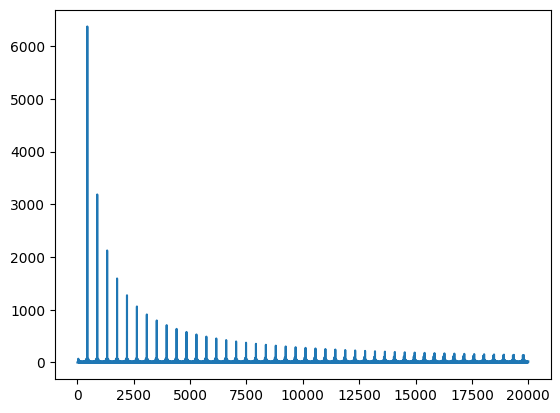

In [34]:
wave = SawtoothSignal().make_wave(duration=0.5, framerate=40000)
spectrum = wave.make_spectrum()
spectrum.plot()

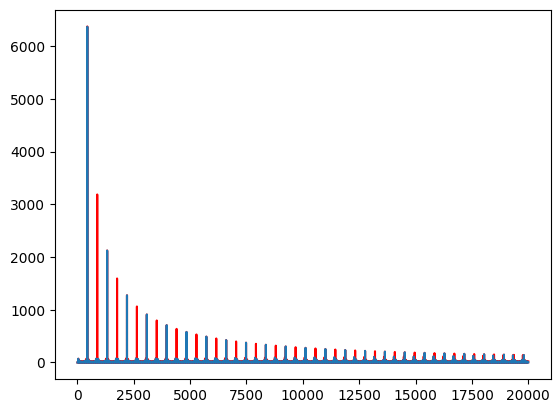

In [38]:
from thinkdsp import SquareSignal

wave.make_spectrum().plot(color='red')
square = SquareSignal(amp=0.5).make_wave(duration=0.5, framerate=40000)
square.make_spectrum().plot()

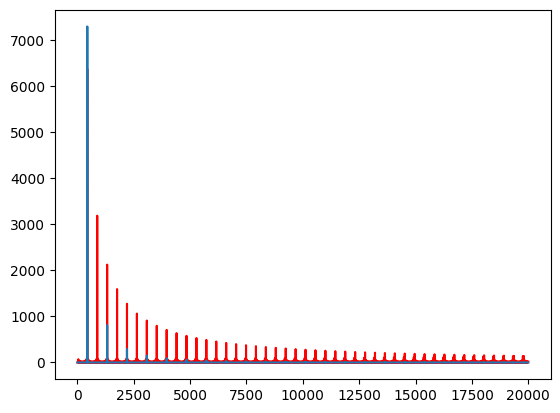

In [40]:
from thinkdsp import TriangleSignal

wave.make_spectrum().plot(color='red')
triangle = TriangleSignal(amp=0.9).make_wave(duration=0.5, framerate=40000)
triangle.make_spectrum().plot()


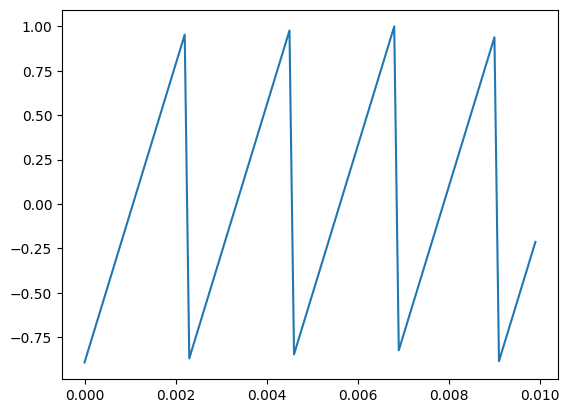

In [41]:
signal = SawtoothSignal(freq=440)
wave = signal.make_wave(duration=0.01, framerate=10000)
wave.plot()

1. Как соотносится его гармоническая структура с треугольным и прямоугольным сигналами?

Спектр пилообразного сигнала содержит все гармоники, а амплитуды гармоник убывают пропорционально.

# Упражнение 2.3

In [42]:
signal = SquareSignal(freq = 1100)
wave = signal.make_wave(duration=0.5, framerate=10000)
wave.make_audio()

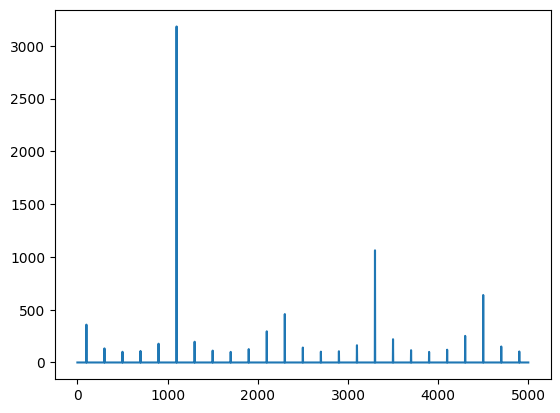

In [43]:
spectrum = wave.make_spectrum()
spectrum.plot()

# Упражнение 2.4

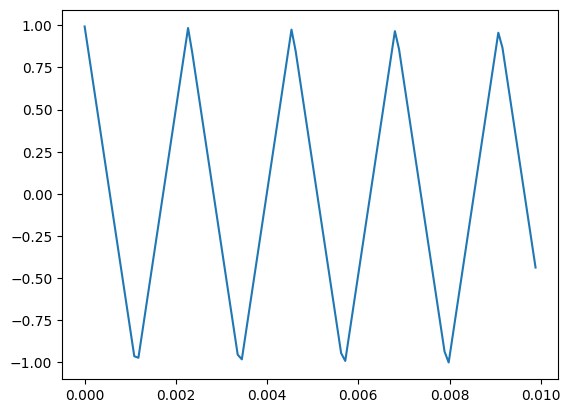

In [52]:
from thinkdsp import TriangleSignal

triangle = TriangleSignal().make_wave(duration=0.01)
triangle.plot()

In [53]:
spectrum = triangle.make_spectrum()
spectrum.hs[0]

np.complex128(1.0436096431476471e-14+0j)

 Это постоянная составляющая DC offset (среднее значение сигнала)

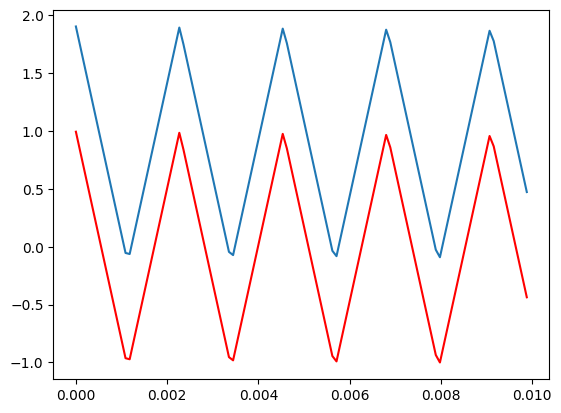

In [54]:
spectrum.hs[0] = 100
triangle.plot(color='red')
spectrum.make_wave().plot()

# Упражнение 2.5


In [89]:
def modify_spectrum(spectrum):
    spectrum.hs[0] = 0
    spectrum.hs[1:] /= spectrum.fs[1:]

    return spectrum

In [94]:
from thinkdsp import SawtoothSignal

signal = SawtoothSignal(freq=440)
wave = signal.make_wave(duration=0.5)
wave.make_audio()

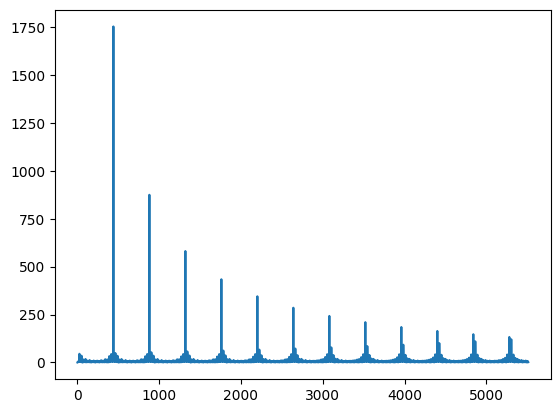

In [95]:
spectrum = wave.make_spectrum()
spectrum.plot()

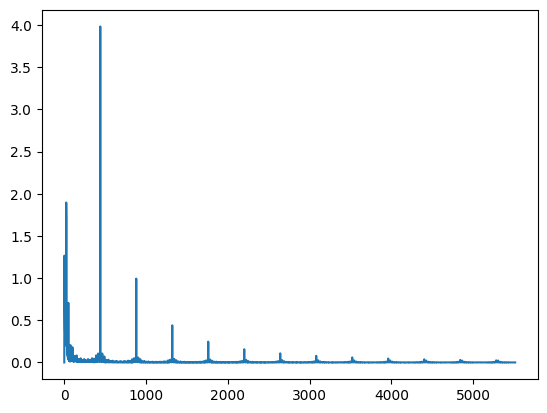

In [91]:
modified = modify_spectrum(spectrum)
modified.plot()

In [93]:
wave2 = modified.make_wave()
wave2.make_audio()

После деления на частоту высокие гармоники значительно ослабевают.

# Упражнение 2.6

In [101]:
from thinkdsp import SinSignal
freqs = range(100, 5000, 100)
amps = [1/f**2 for f in freqs]
signals = [SinSignal(freq=f, amp=a) for f, a in zip(freqs, amps)]
mix = signals[0]
for s in signals[1:]:
    mix = mix + s
wave_new = mix.make_wave(duration=0.5, framerate=11025)
wave_new.make_audio()

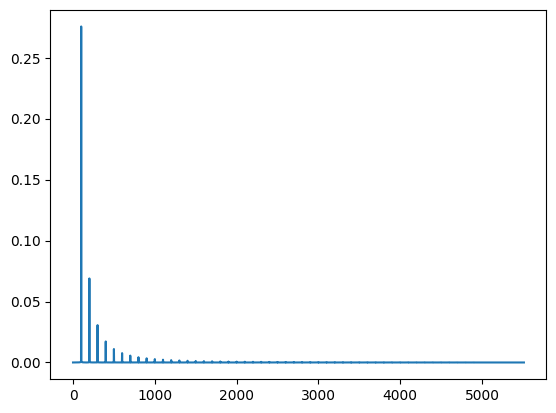

In [102]:
spec_new = wave_new.make_spectrum()
spec_new.plot()